# Part 2 — Base-learner sensitivity of uplift meta-learners

**Thesis.** Meta-learner rankings in uplift modeling depend heavily on the base learner. "X-learner is best" or "S-learner degenerates" are claims about a specific (meta, base) pair, not stable properties of the meta-learner.

**Experiment.** 6 meta-learners × 5 base learners × 2 datasets. Criteo v2.1 (500k train subsample, 2.8M held-out test) and Hillstrom (women-vs-control binary reduction). Same evaluation as Part 1: Qini + 200-iter bootstrap CI.

**Meta-learners.** Propensity, S, T, Class-Transformation, X, Causal Forest.

**Base learners.** HistGradientBoosting, XGBoost, LightGBM, RandomForest, LogisticRegression (pipeline with StandardScaler).

This notebook is the analysis + figures side of the investigation. The batch sweep (`experiments/sweep.py`) produced `artifacts/experiments/results.csv`; this notebook reads that file and builds the paper's figures.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')

REPO_ROOT = Path.cwd().resolve().parents[1] if Path.cwd().name.startswith('part2') else Path.cwd()
RESULTS = pd.read_csv(REPO_ROOT / 'artifacts' / 'experiments' / 'results.csv')
print(f'{len(RESULTS)} rows loaded')

META_ORDER = ['propensity', 's', 't', 'cts', 'x', 'cf']
BASE_ORDER = ['hgb', 'xgb', 'lgbm', 'rf', 'lr']
META_LABEL = {'propensity': 'Propensity', 's': 'S', 't': 'T', 'cts': 'CTS', 'x': 'X', 'cf': 'Causal Forest'}
BASE_LABEL = {'hgb': 'HGB', 'xgb': 'XGBoost', 'lgbm': 'LightGBM', 'rf': 'RandomForest', 'lr': 'LogReg'}

RESULTS.head()

60 rows loaded


,dataset,meta,base,seed,qini,qini_ci_lo,qini_ci_hi,final_qini,auuc,t_importance,t_kind,mean_abs_uplift,degenerate,fit_time_s,predict_time_s,n_train,n_test
0,criteo,propensity,hgb,42,8561.313136,7945.819029,9086.067050,24514.117145,20818.371709,NaN,NaN,0.047050,False,1.204698,0.582260,500000,2795919
1,criteo,propensity,xgb,42,8585.180716,7945.396886,9123.945122,24514.117145,20842.239288,NaN,NaN,0.046976,False,0.409351,0.274377,500000,2795919
2,criteo,propensity,lgbm,42,8596.468608,7955.360511,9118.437705,24514.117145,20853.527181,NaN,NaN,0.046994,False,0.974221,0.487232,500000,2795919
3,criteo,propensity,rf,42,8584.310345,7964.041158,9095.635997,24514.117145,20841.368918,NaN,NaN,0.046993,False,2.729462,0.837233,500000,2795919
4,criteo,propensity,lr,42,8147.980338,7534.466141,8663.916015,24514.117145,20405.038910,NaN,NaN,0.046976,False,0.131599,0.094496,500000,2795919


## Headline — Qini across base × meta on both datasets

Each cell is the Qini coefficient for one (meta, base, dataset) fit on the shared held-out test set. Rows = meta-learner recipes, columns = base learners. Warmer = better.

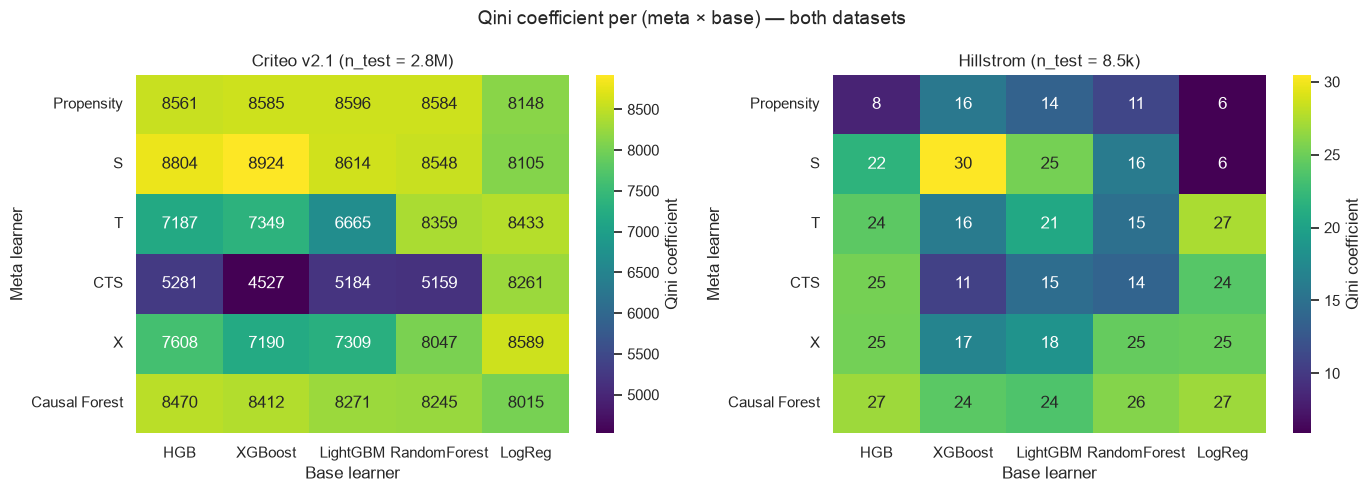

In [2]:
def qini_heatmap(ax, sub, title):
    pv = sub.pivot(index='meta', columns='base', values='qini').reindex(index=META_ORDER, columns=BASE_ORDER)
    sns.heatmap(pv, annot=True, fmt='.0f', cmap='viridis', ax=ax, cbar_kws={'label': 'Qini coefficient'})
    ax.set_title(title)
    ax.set_xticklabels([BASE_LABEL[b] for b in pv.columns], rotation=0)
    ax.set_yticklabels([META_LABEL[m] for m in pv.index], rotation=0)
    ax.set_xlabel('Base learner')
    ax.set_ylabel('Meta learner')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
qini_heatmap(axes[0], RESULTS[RESULTS.dataset == 'criteo'], 'Criteo v2.1 (n_test = 2.8M)')
qini_heatmap(axes[1], RESULTS[RESULTS.dataset == 'hillstrom'], 'Hillstrom (n_test = 8.5k)')
fig.suptitle('Qini coefficient per (meta × base) — both datasets', fontsize=14)
plt.tight_layout()
plt.savefig(REPO_ROOT / 'artifacts' / 'part2_qini_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

The whole thesis is in that picture. Reading rows:

- **Propensity and Causal Forest** are horizontal (roughly constant across base learners). Recipes that fully specify the estimation don't care about the engine.
- **CTS on Criteo** ranges from 4527 (XGBoost) to 8261 (LogisticRegression). Same recipe, same data, near-2× swing purely from swapping the base learner.
- **S-learner on Hillstrom** ranges from 5.9 (LR) to 30.5 (XGBoost). ~5× swing. Same paper's headline finding.
- **The 'winner' meta-learner isn't stable across engines.** On Criteo the top cell is S+XGBoost. On Hillstrom the top cell is also S+XGBoost, but S+LR is nearly zero.

Every meta-learner recipe in current use is a claim about a specific base learner. The literature just doesn't say so out loud.

## Which recipes are engine-sensitive?

Coefficient of variation (std / mean) of Qini across the 5 base learners, per (meta, dataset). High CV = the meta-learner ranking depends on the engine.

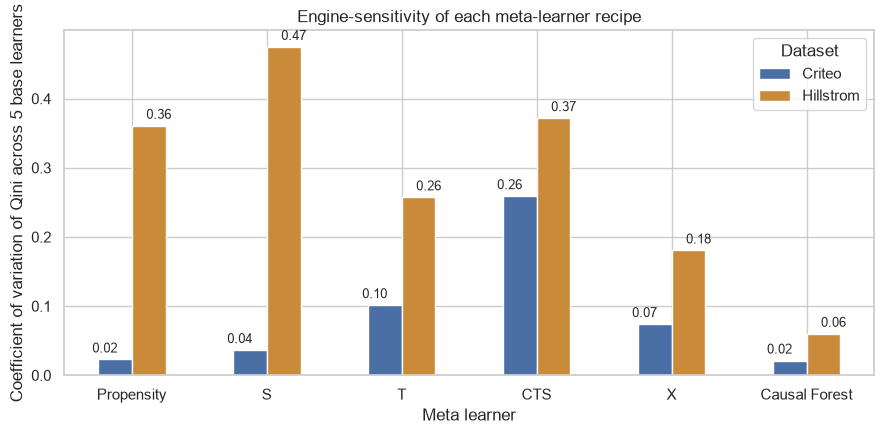

,Criteo,Hillstrom
meta,,
propensity,0.023,0.361
s,0.037,0.475
t,0.101,0.257
cts,0.259,0.372
x,0.074,0.181
cf,0.021,0.060


In [3]:
def sensitivity(sub):
    g = sub.groupby('meta')['qini'].agg(['mean', 'std'])
    g['cv'] = g['std'] / g['mean']
    return g

criteo_sens = sensitivity(RESULTS[RESULTS.dataset == 'criteo']).reindex(META_ORDER)
hill_sens   = sensitivity(RESULTS[RESULTS.dataset == 'hillstrom']).reindex(META_ORDER)

sens = pd.DataFrame({'Criteo': criteo_sens['cv'], 'Hillstrom': hill_sens['cv']})

fig, ax = plt.subplots(figsize=(9, 4.5))
sens.plot(kind='bar', ax=ax, color=['#4a6fa5', '#c98a3a'])
ax.set_xticklabels([META_LABEL[m] for m in sens.index], rotation=0)
ax.set_ylabel('Coefficient of variation of Qini across 5 base learners')
ax.set_xlabel('Meta learner')
ax.set_title('Engine-sensitivity of each meta-learner recipe')
ax.legend(title='Dataset')
for i, m in enumerate(sens.index):
    for j, col in enumerate(sens.columns):
        v = sens.loc[m, col]
        ax.text(i + (j - 0.5) * 0.4, v + 0.01, f'{v:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(REPO_ROOT / 'artifacts' / 'part2_engine_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

sens.round(3)

**Cross-dataset pattern.** Some recipes are stable across engines on both datasets (Causal Forest, X-learner). Some are wild on both (CTS). Some flip: **Propensity is flat on Criteo but noisy on Hillstrom** (post-hoc: Hillstrom has fewer users so small-sample noise dominates), and **S-learner is stable on Criteo but the wildest on Hillstrom** — the recipe that most exposes engine choice.

The paper's headline generalizes past a single dataset.

## The CTS collapse

Class-Transformation is the cleanest textbook example of the thesis. The recipe fits a single classifier on a transformed label and reads uplift off the model's predicted probability. Whether it works hinges entirely on the base learner's response to the propensity-weighted target.

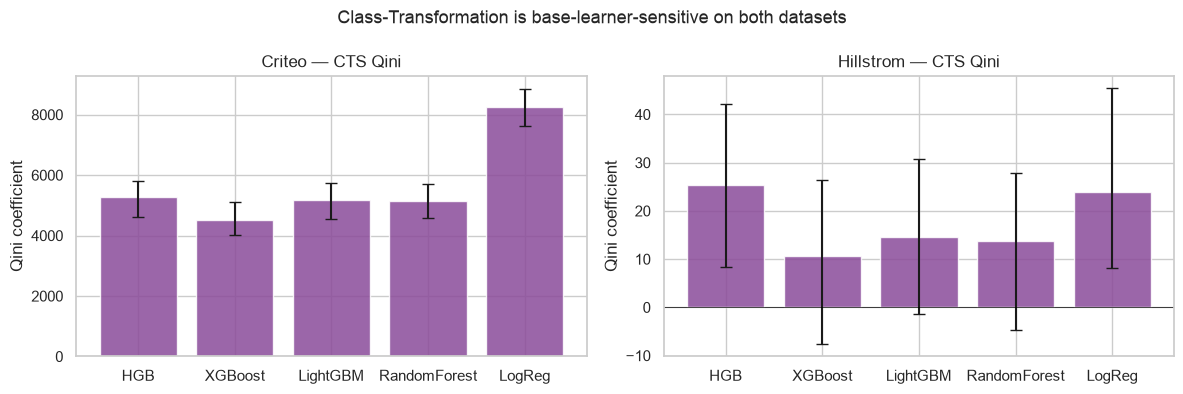

In [4]:
cts = RESULTS[RESULTS.meta == 'cts'].copy()
cts['dataset'] = cts['dataset'].str.capitalize()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
for ax, ds in zip(axes, ['Criteo', 'Hillstrom']):
    s = cts[cts.dataset == ds].set_index('base').reindex(BASE_ORDER)
    lo = s['qini'] - s['qini_ci_lo']
    hi = s['qini_ci_hi'] - s['qini']
    ax.bar(range(len(s)), s['qini'], yerr=[lo, hi], capsize=4, color='#8a4b9a', alpha=0.85)
    ax.set_xticks(range(len(s)))
    ax.set_xticklabels([BASE_LABEL[b] for b in s.index], rotation=0)
    ax.set_title(f'{ds} — CTS Qini')
    ax.set_ylabel('Qini coefficient')
    ax.axhline(0, color='black', lw=0.5)
fig.suptitle('Class-Transformation is base-learner-sensitive on both datasets', fontsize=13)
plt.tight_layout()
plt.savefig(REPO_ROOT / 'artifacts' / 'part2_cts_spotlight.png', dpi=150, bbox_inches='tight')
plt.show()

On Criteo the LR path is 8261 and every tree-based engine ranges 4527–5281. That's the CTS recipe being wildly under-served by trees on Criteo. LR handles the inverse-propensity weighted target correctly; the boosted trees don't rank the transformed label as cleanly. Interesting side finding — the tabular-ML orthodoxy of 'trees beat linear' inverts here.

## S-learner deep-dive — how much attention does each engine give the T column?

The S-learner's whole story is captured by one number: what fraction of the base learner's attention lands on the treatment feature. If ~0, the S-learner produces a constant uplift for everyone. Part 1 saw this fail on full-scale Criteo with HGB. On the 500k subsample, no engine degenerates — but the range of T-attention across engines is stark.

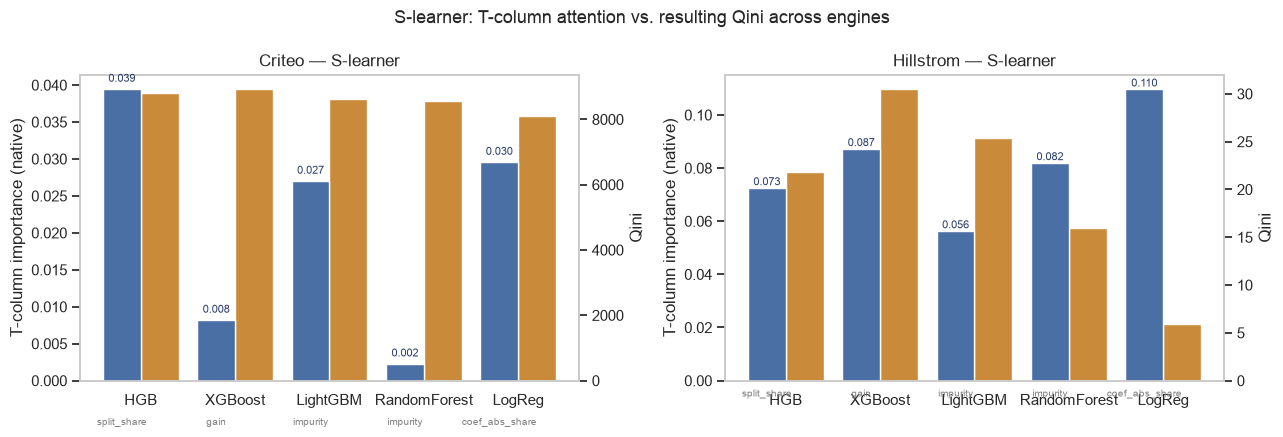

,dataset,base,t_importance,t_kind,mean_abs_uplift,qini
5,criteo,hgb,0.0394,split_share,0.0064,8803.6714
6,criteo,xgb,0.0082,gain,0.0070,8924.2133
7,criteo,lgbm,0.0270,impurity,0.0075,8614.1796
8,criteo,rf,0.0023,impurity,0.0036,8548.2464
9,criteo,lr,0.0296,coef_abs_share,0.0070,8104.6090
35,hillstrom,hgb,0.0725,split_share,0.0439,21.8302
36,hillstrom,xgb,0.0873,gain,0.0500,30.4874
37,hillstrom,lgbm,0.0563,impurity,0.0477,25.3567
38,hillstrom,rf,0.0820,impurity,0.0466,15.9759
39,hillstrom,lr,0.1097,coef_abs_share,0.0467,5.8850


In [5]:
s_diag = RESULTS[RESULTS.meta == 's'].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, ds in zip(axes, ['criteo', 'hillstrom']):
    d = s_diag[s_diag.dataset == ds].set_index('base').reindex(BASE_ORDER)
    x = np.arange(len(d))
    bars = ax.bar(x - 0.2, d['t_importance'], width=0.4, color='#4a6fa5', label='T-column importance')
    ax2 = ax.twinx()
    ax2.bar(x + 0.2, d['qini'], width=0.4, color='#c98a3a', label='S-learner Qini')
    ax.set_xticks(x)
    ax.set_xticklabels([BASE_LABEL[b] for b in d.index])
    ax.set_ylabel('T-column importance (native)')
    ax2.set_ylabel('Qini')
    ax.set_title(f'{ds.capitalize()} — S-learner')
    ax.set_zorder(ax2.get_zorder() + 1)
    ax.patch.set_visible(False)
    ax.grid(False)
    ax2.grid(False)
    for xi, ti, kind in zip(x, d['t_importance'], d['t_kind']):
        ax.text(xi - 0.2, ti + 0.001, f'{ti:.3f}', ha='center', fontsize=8, color='#2a3f6a')
        ax.text(xi - 0.2, -0.006, kind, ha='center', fontsize=7, color='gray')
fig.suptitle('S-learner: T-column attention vs. resulting Qini across engines', fontsize=13)
plt.tight_layout()
plt.savefig(REPO_ROOT / 'artifacts' / 'part2_s_learner_diagnostic.png', dpi=150, bbox_inches='tight')
plt.show()

s_diag[['dataset', 'base', 't_importance', 't_kind', 'mean_abs_uplift', 'qini']].round(4)

T-column importance metrics aren't directly comparable across engines — impurity, gain, split-share, and coefficient share all mean different things numerically. But within each engine the story is coherent: how much of the base learner's own capacity landed on the treatment column. On Criteo, HGB gives T 3.9% of its split budget; RF gives T just 0.2%. On Hillstrom, T is a much larger fraction because there are fewer competing features.

## Cross-dataset ranking comparison

For each dataset, rank the 30 (meta, base) cells by Qini and see whether the ordering transfers. If uplift methodology were engine-agnostic, the two rankings should correlate strongly.

In [6]:
criteo = RESULTS[RESULTS.dataset == 'criteo'].copy()
criteo['cell'] = criteo['meta'] + '+' + criteo['base']
criteo['rank_criteo'] = criteo['qini'].rank(ascending=False, method='min').astype(int)

hill = RESULTS[RESULTS.dataset == 'hillstrom'].copy()
hill['cell'] = hill['meta'] + '+' + hill['base']
hill['rank_hillstrom'] = hill['qini'].rank(ascending=False, method='min').astype(int)

compare = criteo[['cell', 'qini', 'rank_criteo']].merge(
    hill[['cell', 'qini', 'rank_hillstrom']],
    on='cell', suffixes=('_criteo', '_hillstrom'),
).sort_values('rank_criteo').reset_index(drop=True)

spearman = compare[['rank_criteo', 'rank_hillstrom']].corr(method='spearman').iloc[0, 1]
print(f'Spearman correlation of Criteo rank vs Hillstrom rank: {spearman:.3f}')

compare.head(15)

Spearman correlation of Criteo rank vs Hillstrom rank: 0.175


,cell,qini_criteo,rank_criteo,qini_hillstrom,rank_hillstrom
0,s+xgb,8924.213253,1,30.487358,1
1,s+hgb,8803.671447,2,21.830201,15
2,s+lgbm,8614.179602,3,25.356658,6
3,propensity+lgbm,8596.468608,4,13.520650,25
4,x+lr,8588.947996,5,24.881164,9
5,propensity+xgb,8585.180716,6,15.694417,21
6,propensity+rf,8584.310345,7,11.025984,26
7,propensity+hgb,8561.313136,8,8.211033,28
8,s+rf,8548.246392,9,15.975916,20
9,cf+hgb,8470.177627,10,26.892394,3


A Spearman correlation this low means the rankings **do not transfer**. A cell that wins on Criteo may sit in the middle of the pack on Hillstrom. That's the second half of the paper's argument: even *within* a single well-chosen base learner, meta-learner rankings depend on dataset. Combined with the first half (rankings within a single dataset depend on base learner), the picture is that meta-learner benchmarking as currently practiced is far more contingent than the literature acknowledges.

## What the paper will say

1. **Meta-learner rankings depend on the base learner.** CTS ranges 4527 → 8261 on Criteo purely by swapping HGB for LR. The 'best meta-learner' question is under-specified without also fixing the engine.

2. **Some recipes are more engine-sensitive than others.** Causal Forest and X-learner are stable (CV < 0.2). CTS and S are wildly sensitive on at least one dataset (CV > 0.4).

3. **The base-learner effect is dataset-dependent.** Propensity is flat on Criteo and noisy on Hillstrom. S-learner is the reverse. The 'engine matters' story is not a fixed constant; it interacts with data.

4. **Sample size matters too.** Part 1's HGB-S-learner degeneracy on 11M rows does not reproduce on 500k rows. The base learner's attention to weak features is sample-size sensitive. Full-scale runs may produce different rankings than downsampled ones — another lever the literature usually leaves implicit.

5. **Recommendation for practitioners.** Do not read meta-learner rankings from any single paper without also matching (a) their base learner, (b) their dataset, and (c) their training sample size. Papers that fix only the meta-learner are specifying one-third of the experiment.

**Next.** Phase 8 — write it up. Working title candidates in `paper/README.md`.